# Ren-style effective beam polarization angle analysis

This notebook reads GRASP `.grd` files, extracts the complex Ludwig-3 co/cross fields, and computes the effective beam polarization angle using the integrated co/cross power ratio method described in Ren et al. Eqn. 6.

The goal is to compare the effective beam angle for `grid on` versus `grid off`, rather than averaging the local polarization-angle map pixel-by-pixel.

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Directory setup
# Update this path if your .grd files live somewhere else.
data_dir = Path("../data/wire_on_off/")

print(f"Data directory: {data_dir.resolve()}")
print("Files in data directory:")
for f in sorted(os.listdir(data_dir)):
    print(f)

Data directory: /home/ntk5ga/wiregrid/analysis/data/wire_on_off
Files in data directory:
.ipynb_checkpoints
azel_1deg_200on.grd
azel_1deg_off.grd
azel_1deg_on.grd


In [3]:
def load_grasp_grd(filepath):
    """
    Load a GRASP .grd file with complex field components.

    Returns:
        x, y       : 1D coordinate arrays
        F1, F2     : complex 2D arrays (ny, nx)

    Notes:
        For your GRASP files with ICOMP = 3, F1/F2 are already in the
        Ludwig-3 linear co/cross basis, so this notebook treats:

            F1 = Eco
            F2 = Ecx
    """
    filepath = Path(filepath)

    with open(filepath, 'r') as f:
        lines = f.readlines()

    # --- Find the line with grid size (nx ny 0)
    grid_idx = None
    for i, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) == 3:
            try:
                nx = int(parts[0])
                ny = int(parts[1])
                grid_idx = i
                break
            except Exception:
                continue

    if grid_idx is None:
        raise ValueError("Could not find grid size line.")

    # --- Data starts immediately after grid line
    data = np.loadtxt(lines[grid_idx + 1:])

    # --- Extract fields
    F1 = data[:, 0] + 1j * data[:, 1]
    F2 = data[:, 2] + 1j * data[:, 3]

    # --- Reshape
    F1 = F1.reshape((ny, nx))
    F2 = F2.reshape((ny, nx))

    # --- Build coordinate arrays from bounds line
    # Find bounds line (xmin ymin xmax ymax)
    bounds_found = False
    for i in range(grid_idx):
        parts = lines[i].strip().split()
        if len(parts) == 4:
            try:
                xmin, ymin, xmax, ymax = map(float, parts)
                bounds_found = True
            except Exception:
                continue

    if not bounds_found:
        raise ValueError("Could not find coordinate bounds line.")

    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)

    return x, y, F1, F2


def plot_beam(x, y, F1, F2, title="Beam"):
    """
    Quick visualization of total intensity and components.
    """
    I = np.abs(F1)**2 + np.abs(F2)**2

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axs[0].imshow(np.abs(F1), extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
    axs[0].set_title("|F1| / |Eco|")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(np.abs(F2), extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
    axs[1].set_title("|F2| / |Ecx|")
    plt.colorbar(im1, ax=axs[1])

    im2 = axs[2].imshow(I, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
    axs[2].set_title("Total Intensity")
    plt.colorbar(im2, ax=axs[2])

    for ax in axs:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## Ren-style effective beam angle functions

For a trial rotation angle $\phi$, rotate the complex co/cross fields and compute

$$
R(\phi) = \frac{\int_{\Omega_0} |E^\phi_\mathrm{co}|^2 d\Omega}{\int_{\Omega_0} |E^\phi_\mathrm{cx}|^2 d\Omega}.
$$

The effective beam angle is the $\phi$ that maximizes this ratio over the selected main-beam region $\Omega_0$.

In [16]:
def beam_power(Eco, Ecx):
    """Total beam power from complex co/cross fields."""
    return np.abs(Eco)**2 + np.abs(Ecx)**2


def main_beam_mask(I, threshold_db=-20):
    """
    Main beam mask using a power threshold relative to the beam peak.

    threshold_db = -20 corresponds to I >= 0.01 * peak.
    """
    return I >= np.nanmax(I) * 10**(threshold_db / 10)


def circular_mask(x, y, r_max):
    """Circular mask in the x/y coordinate grid."""
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    return R < r_max


def rotate_co_cross(Eco, Ecx, phi_rad):
    """
    Rotate co/cross fields by phi.

    Convention:
        Eco_phi =  Eco cos(phi) + Ecx sin(phi)
        Ecx_phi = -Eco sin(phi) + Ecx cos(phi)
    """
    Eco_phi = Eco * np.cos(phi_rad) + Ecx * np.sin(phi_rad)
    Ecx_phi = -Eco * np.sin(phi_rad) + Ecx * np.cos(phi_rad)
    return Eco_phi, Ecx_phi


def wrap_linear_pol_angle_diff_deg(a_deg, b_deg):
    """
    Difference a-b for linear polarization angles, wrapped to [-90, 90).
    """
    return ((a_deg - b_deg + 90) % 180) - 90


def ren_effective_angle(Eco, Ecx, mask, n_grid=200001, return_curve=False):
    """
    Compute Ren-style effective beam polarization angle.

    Parameters
    ----------
    Eco, Ecx : 2D complex arrays
        Ludwig-3 co/cross fields.
    mask : 2D bool array
        Region of integration Omega_0.
    n_grid : int
        Number of trial angles between -90 and +90 deg.
    return_curve : bool
        If True, also return angle grid and ratio curve.

    Returns
    -------
    phi_best_deg : float
        Angle that maximizes integrated co/cross power ratio.
    ratio_best : float
        Maximum co/cross power ratio.
    Optional:
        phis_deg, ratios
    """
    if Eco.shape != Ecx.shape or Eco.shape != mask.shape:
        raise ValueError("Eco, Ecx, and mask must have matching shapes.")

    Eco_m = Eco[mask]
    Ecx_m = Ecx[mask]

    if Eco_m.size == 0:
        raise ValueError("Mask selected zero pixels.")

    phis = np.linspace(-np.pi / 2, np.pi / 2, n_grid, endpoint=False)
    ratios = np.empty_like(phis)

    for i, phi in enumerate(phis):
        Eco_r, Ecx_r = rotate_co_cross(Eco_m, Ecx_m, phi)
        co_power = np.sum(np.abs(Eco_r)**2)
        cx_power = np.sum(np.abs(Ecx_r)**2)
        ratios[i] = co_power / cx_power

    best_idx = np.nanargmax(ratios)
    phi_best_deg = np.degrees(phis[best_idx])
    ratio_best = ratios[best_idx]

    if return_curve:
        return phi_best_deg, ratio_best, np.degrees(phis), ratios
    return phi_best_deg, ratio_best


def compare_ren_angles(Eco_off, Ecx_off, Eco_on, Ecx_on, mask, label="mask", n_grid=200001):
    """Run Ren-style angle analysis for grid-off and grid-on fields using one shared mask."""
    phi_off, ratio_off = ren_effective_angle(Eco_off, Ecx_off, mask, n_grid=n_grid)
    phi_on, ratio_on = ren_effective_angle(Eco_on, Ecx_on, mask, n_grid=n_grid)
    delta_phi = wrap_linear_pol_angle_diff_deg(phi_on, phi_off)

    result = {
        "region": label,
        "pixels": int(np.sum(mask)),
        "phi_off_deg": phi_off,
        "phi_on_deg": phi_on,
        "delta_phi_on_minus_off_deg": delta_phi,
        "ratio_off": ratio_off,
        "ratio_on": ratio_on,
    }
    return result


def print_ren_result(result):
    """Pretty-print one compare_ren_angles result dictionary."""
    print(f"--- Ren-style effective beam angle: {result['region']} ---")
    print(f"pixels                         = {result['pixels']}")
    print(f"phi_off                        = {result['phi_off_deg']:.8e} deg")
    print(f"phi_on                         = {result['phi_on_deg']:.8e} deg")
    print(f"delta phi, on - off            = {result['delta_phi_on_minus_off_deg']:.8e} deg")
    print(f"co/cross ratio off             = {result['ratio_off']:.8e}")
    print(f"co/cross ratio on              = {result['ratio_on']:.8e}")

## Run the analysis

Set the filenames here. The defaults use your 200-wire grid-on/off names from the previous notebook.

In [11]:
# Choose input files
grid_off_file = data_dir / "azel_1deg_off.grd"
grid_on_file  = data_dir / "azel_1deg_200on.grd"

# Load GRASP fields
x_off, y_off, Eco_off, Ecx_off = load_grasp_grd(grid_off_file)
x_on,  y_on,  Eco_on,  Ecx_on  = load_grasp_grd(grid_on_file)

# Basic sanity checks
assert np.allclose(x_off, x_on), "x grids differ between off and on files"
assert np.allclose(y_off, y_on), "y grids differ between off and on files"
assert Eco_off.shape == Eco_on.shape == Ecx_off.shape == Ecx_on.shape

print("Loaded files successfully.")
print(f"grid shape: {Eco_off.shape}")
print(f"x range: {x_off.min()} to {x_off.max()}")
print(f"y range: {y_off.min()} to {y_off.max()}")

Loaded files successfully.
grid shape: (1001, 1001)
x range: -0.5 to 0.5
y range: -0.5 to 0.5


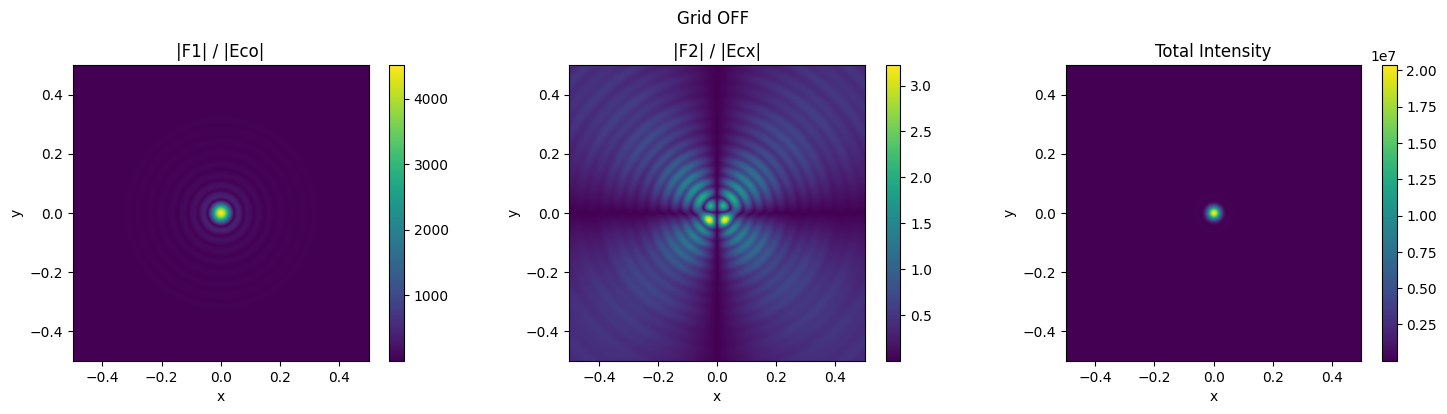

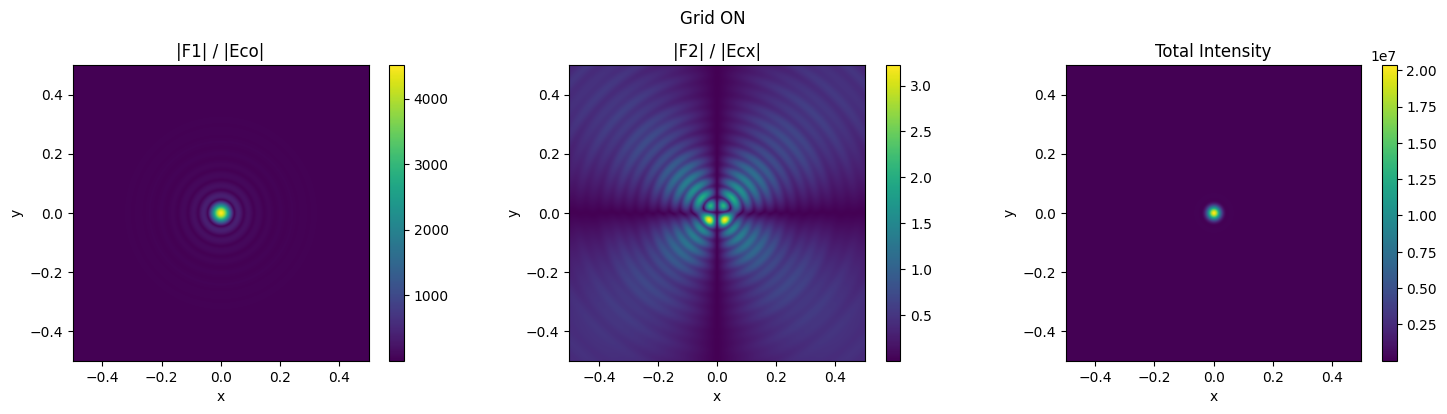

In [12]:
# Optional quick plots
plot_beam(x_off, y_off, Eco_off, Ecx_off, title="Grid OFF")
plot_beam(x_on,  y_on,  Eco_on,  Ecx_on,  title="Grid ON")

In [13]:
# Build masks
I_off = beam_power(Eco_off, Ecx_off)
I_on  = beam_power(Eco_on,  Ecx_on)

# Use one shared mask for both runs. The no-grid beam is a clean reference.
mask_m20db = main_beam_mask(I_off, threshold_db=-20)
mask_r005  = circular_mask(x_off, y_off, r_max=0.05)
mask_r002  = circular_mask(x_off, y_off, r_max=0.02)

print(f"> -20 dB mask pixels: {mask_m20db.sum()}")
print(f"r < 0.05 mask pixels: {mask_r005.sum()}")
print(f"r < 0.02 mask pixels: {mask_r002.sum()}")

> -20 dB mask pixels: 5049
r < 0.05 mask pixels: 7833
r < 0.02 mask pixels: 1245


In [24]:
def ren_effective_angle_analytic(Eco, Ecx, mask):
    Eco_m = Eco[mask]
    Ecx_m = Ecx[mask]

    A = np.sum(np.abs(Eco_m)**2)
    B = np.sum(np.abs(Ecx_m)**2)
    C = np.real(np.sum(Eco_m * np.conj(Ecx_m)))

    # angle that diagonalizes the integrated 2x2 polarization power matrix
    phi = 0.5 * np.arctan2(2*C, A - B)

    Eco_r = Eco_m*np.cos(phi) + Ecx_m*np.sin(phi)
    Ecx_r = -Eco_m*np.sin(phi) + Ecx_m*np.cos(phi)

    ratio = np.sum(np.abs(Eco_r)**2) / np.sum(np.abs(Ecx_r)**2)

    return np.degrees(phi), ratio


In [26]:
mask = main_beam_mask(I_off, threshold_db=-100)
phi_off, ratio_off = ren_effective_angle_analytic(Eco_off, Ecx_off, mask)
phi_on, ratio_on = ren_effective_angle_analytic(Eco_on, Ecx_on, mask)

delta_phi = ((phi_on - phi_off + 90) % 180) - 90

print(f"phi_off   = {phi_off:.12e} deg")
print(f"phi_on    = {phi_on:.12e} deg")
print(f"delta_phi = {delta_phi:.12e} deg")
print(f"ratio_off = {ratio_off:.12e}")
print(f"ratio_on  = {ratio_on:.12e}")

phi_off   = 5.693843774791e-09 deg
phi_on    = 1.335458174492e-08 deg
delta_phi = 7.660744927307e-09 deg
ratio_off = 1.211339345857e+05
ratio_on  = 1.211094953617e+05
